# Blockchain Alpha — Random 10k Wallet Longitudinal Study

Tests the core thesis directly: can we find wallets in the general ETH population whose daily buy actions predict positive forward returns?

Uses a random sample from the existing discovery pool — no convexity pre-selection. Fetches 2.5 years of daily balance data per wallet.

**Three-phase pipeline:**
1. Random sample + historical balance probe (~$0.14)
2. Daily balance fetch across full window (~$85)
3. Forward return skill scoring with FDR correction

**Fully restart-safe:** probe checkpoint + daily balance store both support warm-starting after crashes.

**Key question:** Of ~6-10k random wallets with 2.5 years of data, how many show statistically significant forward return predictability? And how does that compare to the expert pool selected by convexity scoring?

## 1. Configuration & imports

In [1]:
from claude_refactor_core_utils import *
from datetime import date, timedelta
import datetime
import pandas as pd
import numpy as np
import os
import json
import random
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import binom
from statsmodels.stats.multitest import multipletests

# --- Required keys ---
ALCHEMY_API_KEY   = "8J0Ou3_XsuWVbOiZ0xpEvioGx7k0wab9"
ETHERSCAN_API_KEY = "GH6FVBANEIR1HS6PEN36XMYQRY2IDEAAXR"
assert ALCHEMY_API_KEY,   "Set ALCHEMY_API_KEY"
assert ETHERSCAN_API_KEY, "Set ETHERSCAN_API_KEY"

# --- Window ---
HISTORY_START_DATE = date(2024, 1, 1)    # balance history start (slight warmup before train)
FETCH_END_DATE     = date.today() - timedelta(days=21)
TRAIN_END_DATE     = date(2025, 8, 1)    # for period tagging

# --- Sampling ---
TARGET_WALLETS     = 10_000              # target after history probe
OVERSAMPLE_FACTOR  = 8                   # probe this many times target to hit ~10k survivors
RANDOM_SEED        = 42

# --- Signal config ---
MIN_DELTA_ETH      = 0.005
HORIZONS           = [1, 3, 5, 10]      # forward return horizons in days
FDR_ALPHA          = 0.05               # false discovery rate threshold

# --- File paths ---
EXISTING_BLOCK_MAP_CSV    = '/home/colin/projects/blockchain_alpha/data/warm_start_block_df.csv'
DISCOVERY_CHECKPOINT_CSV  = '/home/colin/projects/blockchain_alpha/data/discovery_checkpoint.csv'
PROBE_CHECKPOINT_CSV      = '/home/colin/projects/blockchain_alpha/data/random_10k_probe_checkpoint.csv'
BALANCE_STORE_CSV         = '/home/colin/projects/blockchain_alpha/data/balance_store_random_10k.csv'
QUALIFIED_WALLETS_CSV     = '/home/colin/projects/blockchain_alpha/data/random_10k_qualified_wallets.csv'
SKILL_RESULTS_CSV         = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'

print(f"History window: {HISTORY_START_DATE} to {FETCH_END_DATE}")
print(f"Window length:  {(FETCH_END_DATE - HISTORY_START_DATE).days} days")
print(f"Target wallets: {TARGET_WALLETS:,}")
print(f"Oversample:     {TARGET_WALLETS * OVERSAMPLE_FACTOR:,} addresses to probe")


History window: 2024-01-01 to 2026-03-24
Window length:  813 days
Target wallets: 10,000
Oversample:     80,000 addresses to probe


## 2. Build candidate address pool

Union all addresses from the existing discovery checkpoint. Random sample for historical balance probing.

In [2]:
# ============================================================
# Build candidate pool from existing discovery checkpoint
# Union all hist_active_addr across all discovery days
# ============================================================

if not os.path.exists(DISCOVERY_CHECKPOINT_CSV):
    raise FileNotFoundError(f"Discovery checkpoint not found: {DISCOVERY_CHECKPOINT_CSV}")

checkpoint_df = pd.read_csv(DISCOVERY_CHECKPOINT_CSV)
print(f"Discovery checkpoint: {len(checkpoint_df)} days")

# Union all addresses across all discovery days
all_discovered = set()
for _, row in checkpoint_df.iterrows():
    addrs = json.loads(row['hist_active_addr'])
    all_discovered.update(a.lower().strip() for a in addrs)

print(f"Total unique addresses in discovery pool: {len(all_discovered):,}")
print()

# Random sample for probing
random.seed(RANDOM_SEED)
n_to_probe = min(TARGET_WALLETS * OVERSAMPLE_FACTOR, len(all_discovered))
sample_pool = sorted(all_discovered)
random.shuffle(sample_pool)
addresses_to_probe = sample_pool[:n_to_probe]

print(f"Random sample to probe: {len(addresses_to_probe):,}")
print(f"Expected survivors (~12% pass rate): {int(len(addresses_to_probe) * 0.12):,}")


Discovery checkpoint: 20 days
Total unique addresses in discovery pool: 50,794

Random sample to probe: 50,794
Expected survivors (~12% pass rate): 6,095


## 3. Block map

In [3]:
# Build/update block map
block_df = build_or_update_block_map(
    start_date=str(HISTORY_START_DATE),
    end_date=str(FETCH_END_DATE),
    period="day",
    etherscan_api_key=ETHERSCAN_API_KEY,
    existing_csv_path=EXISTING_BLOCK_MAP_CSV,
    sleep_sec=0.51,
    write_back=True
)
block_map = dict(zip(block_df['timestamp'], block_df['block_number']))
print(f"Block map: {len(block_map):,} dates")


Warm-start: loaded 2290 rows from /home/colin/projects/blockchain_alpha/data/warm_start_block_df.csv
Block map is up to date — no Etherscan queries needed.
Block map written to /home/colin/projects/blockchain_alpha/data/warm_start_block_df.csv (2290 rows)
Block map: 2,290 dates


/home/colin/projects/blockchain_alpha/notebooks/claude_refactor_core_utils.py:338: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing_df, new_df], ignore_index=True)


## 4. Phase 1 — Historical balance probe (restart-safe)

Check which addresses have non-zero ETH balance at `HISTORY_START_DATE`. Results saved to `PROBE_CHECKPOINT_CSV` after each batch. **Restart-safe:** already-probed addresses are skipped.

In [6]:
# ============================================================
# Phase 1: Historical balance probe
# Check which addresses have non-zero ETH balance at HISTORY_START_DATE
# Restart-safe: saves results to probe checkpoint
# ============================================================

def load_probe_checkpoint(path):
    """Load previously probed addresses."""
    if not os.path.exists(path):
        return {}, set()
    df = pd.read_csv(path)
    qualified = set(df[df['has_balance']==True]['address'].tolist())
    probed    = set(df['address'].tolist())
    return qualified, probed

def save_probe_results(path, results_batch):
    """Append batch of probe results to checkpoint."""
    rows = pd.DataFrame(results_batch)
    if os.path.exists(path):
        rows.to_csv(path, mode='a', header=False, index=False)
    else:
        rows.to_csv(path, index=False)

# Load checkpoint
qualified_set, already_probed = load_probe_checkpoint(PROBE_CHECKPOINT_CSV)
print(f"Already probed: {len(already_probed):,} addresses")
print(f"Already qualified: {len(qualified_set):,} addresses")

# Find remaining addresses to probe
remaining = [a for a in addresses_to_probe if a not in already_probed]
print(f"Remaining to probe: {len(remaining):,}")
print()

# Get block number for history start date
block_number_history = block_map.get(HISTORY_START_DATE)
assert block_number_history, f"No block found for {HISTORY_START_DATE}"

if remaining:
    print(f"Probing {len(remaining):,} addresses for balance at {HISTORY_START_DATE}...")
    new_qualified = get_addresses_with_nonzero_balance(
        addresses=remaining,
        block_number=block_number_history,
        alchemy_api_key=ALCHEMY_API_KEY,
        max_addresses=len(remaining)
    )

    # Save results
    batch = [
        {'address': a, 'has_balance': a in set(new_qualified)}
        for a in remaining
    ]
    save_probe_results(PROBE_CHECKPOINT_CSV, batch)
    qqualified_set.update(set(new_qualified))
    print(f"New qualified: {len(new_qualified):,}")
else:
    print("All addresses already probed — loading from checkpoint.")

# Final qualified list
qualified_wallets = sorted(qualified_set)
print()
print(f"Total qualified wallets (non-zero balance at {HISTORY_START_DATE}): {len(qualified_wallets):,}")
print(f"Pass rate: {len(qualified_wallets)/len(addresses_to_probe)*100:.1f}%")

# Sample down to TARGET_WALLETS if we have more
if len(qualified_wallets) > TARGET_WALLETS:
    random.seed(RANDOM_SEED)
    qualified_wallets = sorted(random.sample(qualified_wallets, TARGET_WALLETS))
    print(f"Sampled down to {len(qualified_wallets):,}")

# Save final qualified list
pd.DataFrame({'address': qualified_wallets}).to_csv(QUALIFIED_WALLETS_CSV, index=False)
print(f"Qualified wallets saved: {QUALIFIED_WALLETS_CSV}")


Already probed: 50,794 addresses
Already qualified: 45,514 addresses
Remaining to probe: 0

All addresses already probed — loading from checkpoint.

Total qualified wallets (non-zero balance at 2024-01-01): 45,514
Pass rate: 89.6%
Sampled down to 10,000
Qualified wallets saved: /home/colin/projects/blockchain_alpha/data/random_10k_qualified_wallets.csv


## 5. Phase 2 — Daily balance fetch (restart-safe)

Fetch ETH balance for every qualified wallet on every trading day from `HISTORY_START_DATE` to `FETCH_END_DATE`. Saves to `BALANCE_STORE_CSV` after every date. **Restart-safe:** already-fetched (address, date) pairs are skipped.

In [7]:
# ============================================================
# Phase 2: Daily balance fetch
# Fetch ETH balance for every qualified wallet on every trading day
# Saves after every date — restart-safe
# ============================================================

# Load price history to get all trading dates
df_price = load_eth_usd_yahoo(start="2020-01-01")
df_price['date'] = pd.to_datetime(df_price['date'])
all_dates = sorted(
    df_price.loc[
        (df_price['date'].dt.date >= HISTORY_START_DATE) &
        (df_price['date'].dt.date <= FETCH_END_DATE),
        'date'
    ].dt.date.tolist()
)
all_dates = [d for d in all_dates if d in block_map]

n_pairs = len(qualified_wallets) * len(all_dates)
cost_est = n_pairs * 19 / 1_000_000 * 0.45

print(f"Qualified wallets:  {len(qualified_wallets):,}")
print(f"Trading dates:      {len(all_dates):,}")
print(f"Total pairs:        {n_pairs:,}")
print(f"Estimated cost:     ${cost_est:.2f}")
print()

def load_already_fetched(store_path):
    """Load set of already-fetched (address, date) pairs."""
    if not os.path.exists(store_path):
        return set()
    df = pd.read_csv(store_path, usecols=['address','date'])
    df['date']    = pd.to_datetime(df['date'], format='mixed').dt.normalize()
    df['address'] = df['address'].str.lower().str.strip()
    return set(zip(df['address'], df['date']))

def filter_schedule(schedule_df, already_fetched):
    """Filter schedule to unfetched pairs."""
    sched = schedule_df.copy()
    sched['date']    = pd.to_datetime(sched['date']).dt.normalize()
    sched['address'] = sched['address'].str.lower().str.strip()
    mask = sched.apply(
        lambda r: (r['address'], r['date']) not in already_fetched, axis=1
    )
    n_skip = (~mask).sum()
    if n_skip > 0:
        print(f"  Skipping {n_skip:,} already-fetched pairs")
    return sched[mask].reset_index(drop=True)

# Load already-fetched pairs
print("Loading already-fetched pairs...")
already_fetched = load_already_fetched(BALANCE_STORE_CSV)
print(f"Already fetched: {len(already_fetched):,} pairs "
      f"({len(already_fetched)/n_pairs*100:.1f}% complete)")
print()

# Fetch day by day
for i, event_date in enumerate(all_dates):
    event_date_str = str(event_date)
    event_ts       = pd.Timestamp(event_date).normalize()

    # Build schedule for this date
    sched_day = pd.DataFrame({
        'address': qualified_wallets,
        'date':    event_ts
    })

    sched_new = filter_schedule(sched_day, already_fetched)

    if not sched_new.empty:
        bal = fetch_balances_for_schedule(
            schedule=sched_new,
            block_df=block_df,
            alchemy_api_key=ALCHEMY_API_KEY,
            batch_size=100,
            max_concurrency=30,
            rps=25.0,
            progress_every=200,
            block_date_col="timestamp",
            label=f"rnd10k-{event_date_str}"
        )

        if not bal.empty:
            # Append to store
            if os.path.exists(BALANCE_STORE_CSV):
                bal.to_csv(BALANCE_STORE_CSV, mode='a', header=False, index=False)
            else:
                bal.to_csv(BALANCE_STORE_CSV, index=False)
            # Update already-fetched cache
            bal['date_norm'] = pd.to_datetime(bal['date'], format='mixed').dt.normalize()
            newly_fetched = set(zip(
                bal['address'].str.lower().str.strip(),
                bal['date_norm']
            ))
            already_fetched.update(newly_fetched)

    # Progress every 30 days
    if (i + 1) % 30 == 0 or (i + 1) == len(all_dates):
        pct = len(already_fetched) / n_pairs * 100
        print(f"[{i+1}/{len(all_dates)}] {event_date_str} — "
              f"{len(already_fetched):,} pairs fetched ({pct:.1f}%)")

print("\nPhase 2 complete.")


Qualified wallets:  10,000
Trading dates:      788
Total pairs:        7,880,000
Estimated cost:     $67.37

Loading already-fetched pairs...
Already fetched: 0 pairs (0.0% complete)

[rnd10k-2024-01-01] 100/100 batches (100.0%)
[rnd10k-2024-01-02] 100/100 batches (100.0%)
[rnd10k-2024-01-03] 100/100 batches (100.0%)
[rnd10k-2024-01-04] 100/100 batches (100.0%)
[rnd10k-2024-01-05] 100/100 batches (100.0%)
[rnd10k-2024-01-06] 100/100 batches (100.0%)
[rnd10k-2024-01-07] 100/100 batches (100.0%)
[rnd10k-2024-01-08] 100/100 batches (100.0%)
[rnd10k-2024-01-09] 100/100 batches (100.0%)
[rnd10k-2024-01-10] 100/100 batches (100.0%)
[rnd10k-2024-01-11] 100/100 batches (100.0%)
[rnd10k-2024-01-12] 100/100 batches (100.0%)
[rnd10k-2024-01-13] 100/100 batches (100.0%)
[rnd10k-2024-01-14] 100/100 batches (100.0%)
[rnd10k-2024-01-15] 100/100 batches (100.0%)
[rnd10k-2024-01-17] 100/100 batches (100.0%)
[rnd10k-2024-01-18] 100/100 batches (100.0%)
[rnd10k-2024-01-19] 100/100 batches (100.0%)
[rnd10

## 6. Load & clean balance store

In [8]:
# ============================================================
# Load and clean the random 10k balance store
# ============================================================

print("Loading balance store...")
raw = pd.read_csv(BALANCE_STORE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.normalize()
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')
raw['block_number']= pd.to_numeric(raw['block_number'], errors='coerce').astype('Int64')

# Deduplicate
balances = (
    raw
    .sort_values(['address', 'date', 'block_number'])
    .groupby(['address', 'date'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
balances['balance_eth'] = balances['balance_wei'] / 1e18

print(f"Balance store: {balances.shape[0]:,} rows")
print(f"Unique addresses: {balances['address'].nunique():,}")
print(f"Date range: {balances['date'].min().date()} to {balances['date'].max().date()}")

expected = balances['address'].nunique() * len(all_dates)
print(f"Coverage: {balances.shape[0]/expected*100:.1f}% of expected pairs")


Loading balance store...


/tmp/ipykernel_5102/2187465457.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(BALANCE_STORE_CSV)


Balance store: 7,880,000 rows
Unique addresses: 10,000
Date range: 2024-01-01 to 2026-03-24
Coverage: 100.0% of expected pairs


## 7. Infer daily actions

Buy/sell/hold from day-over-day balance delta. Filter to wallets with >= 20 buy trades.

In [9]:
# ============================================================
# Infer daily buy/sell/hold actions from balance deltas
# ============================================================

df_pos = balances.sort_values(['address', 'date']).copy()
df_pos['delta_eth'] = df_pos.groupby('address')['balance_eth'].diff()

def classify_action(delta):
    if pd.isna(delta): return None
    if delta >  MIN_DELTA_ETH: return 'buy'
    if delta < -MIN_DELTA_ETH: return 'sell'
    return 'hold'

df_pos['action'] = df_pos['delta_eth'].apply(classify_action)
daily_actions = df_pos.dropna(subset=['action']).copy()

print(f"Daily action observations: {len(daily_actions):,}")
print(f"Unique wallets with actions: {daily_actions['address'].nunique():,}")
print()
print("Action distribution:")
print(daily_actions['action'].value_counts())
print()

# Filter: only keep wallets with enough trades to be statistically meaningful
trade_counts = daily_actions[daily_actions['action']=='buy'].groupby('address').size()
active_wallets = trade_counts[trade_counts >= 20].index.tolist()
print(f"Wallets with >= 20 buy trades: {len(active_wallets):,}")

daily_actions_filtered = daily_actions[daily_actions['address'].isin(active_wallets)].copy()
print(f"Filtered action observations: {len(daily_actions_filtered):,}")


Daily action observations: 7,870,000
Unique wallets with actions: 10,000

Action distribution:
action
hold    6002289
sell     935615
buy      932096
Name: count, dtype: int64

Wallets with >= 20 buy trades: 8,077
Filtered action observations: 6,356,599


## 8. Merge forward returns

In [10]:
# ============================================================
# Merge forward returns onto daily actions
# ============================================================

# Load price data and compute forward returns
df_price_full = load_eth_usd_yahoo(start="2020-01-01")
df_price_full['date'] = pd.to_datetime(df_price_full['date'])
df_price_full = df_price_full.sort_values('date').reset_index(drop=True)

for h in HORIZONS:
    df_price_full[f'fwd_return_{h}d']    = (
        df_price_full['close'].shift(-h) - df_price_full['close']
    ) / df_price_full['close'] * 100
    df_price_full[f'fwd_direction_{h}d'] = np.sign(df_price_full[f'fwd_return_{h}d'])

df_price_full['period'] = df_price_full['date'].apply(
    lambda d: 'train' if d.date() < TRAIN_END_DATE
              else ('test' if d.date() <= FETCH_END_DATE else 'future')
)

# Merge
trade_df = daily_actions_filtered.merge(
    df_price_full[['date','close','period'] +
                   [f'fwd_return_{h}d' for h in HORIZONS] +
                   [f'fwd_direction_{h}d' for h in HORIZONS]],
    on='date', how='inner'
)

print(f"Trade observations with price data: {len(trade_df):,}")
print(f"Unique wallets: {trade_df['address'].nunique():,}")
print(f"Train obs: {(trade_df['period']=='train').sum():,}")
print(f"Test obs:  {(trade_df['period']=='test').sum():,}")


Trade observations with price data: 6,356,599
Unique wallets: 8,077
Train obs: 4,515,043
Test obs:  1,841,556


## 9. Wallet-level skill scoring

For each wallet at each horizon: t-test of buy forward returns vs population baseline. FDR correction (Benjamini-Hochberg) applied per horizon. With 900+ days of data per wallet, individual-level tests now have real statistical power.

In [13]:
# # ============================================================
# # Wallet-level forward return skill scoring
# # For each wallet: do their buys precede positive returns?
# # Test against population baseline, apply FDR correction
# # ============================================================

# print("Computing wallet-level skill scores...")
# print()

# skill_rows = []

# # Population baseline forward returns
# for h in HORIZONS:
#     col = f'fwd_return_{h}d'
#     baseline_mean = trade_df[col].mean()
#     baseline_dir  = (trade_df[f'fwd_direction_{h}d'] > 0).mean()

#     # Per-wallet analysis
#     for addr, grp in trade_df.groupby('address'):
#         buys  = grp[grp['action'] == 'buy']
#         sells = grp[grp['action'] == 'sell']

#         if len(buys) < 10:
#             continue

#         buy_returns = buys[col].dropna()
#         base_returns = trade_df[col].dropna()

#         # t-test: buy forward returns vs population
#         t_stat, p_val = stats.ttest_ind(buy_returns, base_returns)

#         # Direction accuracy
#         buy_dir_acc = (buys[f'fwd_direction_{h}d'].dropna() > 0).mean()

#         skill_rows.append({
#             'address':      addr,
#             'horizon':      h,
#             'n_buy_trades': len(buys),
#             'n_sell_trades':len(sells),
#             'buy_mean_return': buy_returns.mean(),
#             'baseline_mean':   baseline_mean,
#             'return_diff':  buy_returns.mean() - baseline_mean,
#             'dir_accuracy': buy_dir_acc,
#             'baseline_dir': baseline_dir,
#             'p_value_raw':  p_val,
#         })

# skill_df = pd.DataFrame(skill_rows)

# # Apply FDR correction per horizon
# print("Applying FDR correction per horizon...")
# for h in HORIZONS:
#     mask = skill_df['horizon'] == h
#     pvals = skill_df.loc[mask, 'p_value_raw'].values
#     reject, pvals_fdr, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method='fdr_bh')
#     skill_df.loc[mask, 'p_value_fdr'] = pvals_fdr
#     skill_df.loc[mask, 'significant_fdr'] = reject
#     skill_df.loc[mask, 'significant_raw'] = pvals < 0.05

#     n_sig_fdr = reject.sum()
#     n_sig_raw = (pvals < 0.05).sum()
#     n_wallets = mask.sum()
#     n_expected = int(n_wallets * 0.05)

#     print(f"  {h}d horizon ({n_wallets:,} wallets tested):")
#     print(f"    Significant (FDR corrected): {n_sig_fdr}")
#     print(f"    Significant (uncorrected p<0.05): {n_sig_raw} (random expected: ~{n_expected})")

# print()

# # Positive-skill wallets: significant FDR AND positive return diff
# positive_skill = skill_df[
#     skill_df['significant_fdr'] &
#     (skill_df['return_diff'] > 0)
# ]
# print(f"Wallets with positive, FDR-significant buy skill:")
# print(f"  Across any horizon: {positive_skill['address'].nunique():,}")
# for h in HORIZONS:
#     n = positive_skill[positive_skill['horizon']==h]['address'].nunique()
#     print(f"  At {h}d horizon: {n}")



from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np

print("Computing wallet-level skill scores (vectorized)...")

skill_rows = []

# Pre-compute population baseline stats per horizon outside the loop
baseline_stats = {}
for h in HORIZONS:
    col = f'fwd_return_{h}d'
    dir_col = f'fwd_direction_{h}d'
    baseline_stats[h] = {
        'mean':    trade_df[col].mean(),
        'std':     trade_df[col].std(),
        'n':       trade_df[col].notna().sum(),
        'dir_acc': (trade_df[dir_col].dropna() > 0).mean()
    }

# Pre-filter to buys only and pre-group — do this ONCE outside all loops
buys_df = trade_df[trade_df['action'] == 'buy'].copy()
sells_df = trade_df[trade_df['action'] == 'sell'].copy()

print(f"Buy observations: {len(buys_df):,}")
print(f"Processing {len(active_wallets):,} wallets × {len(HORIZONS)} horizons...")

# Group once
buy_groups  = buys_df.groupby('address')
sell_groups = sells_df.groupby('address')

for h_idx, h in enumerate(HORIZONS):
    col     = f'fwd_return_{h}d'
    dir_col = f'fwd_direction_{h}d'

    b_stats = baseline_stats[h]
    base_mean = b_stats['mean']
    base_std  = b_stats['std']
    base_n    = b_stats['n']
    base_dir  = b_stats['dir_acc']

    print(f"  Horizon {h}d...")

    for addr in active_wallets:
        if addr not in buy_groups.groups:
            continue

        buy_ret = buy_groups.get_group(addr)[col].dropna()
        if len(buy_ret) < 10:
            continue

        n_sell = 0
        if addr in sell_groups.groups:
            n_sell = len(sell_groups.get_group(addr))

        # Welch t-test against population
        buy_mean = buy_ret.mean()
        buy_std  = buy_ret.std()
        buy_n    = len(buy_ret)

        # Manual Welch t-test (faster than ttest_ind on large baseline)
        se = np.sqrt(buy_std**2 / buy_n + base_std**2 / base_n)
        if se == 0:
            p_val = 1.0
        else:
            t_stat = (buy_mean - base_mean) / se
            df_w   = (buy_std**2/buy_n + base_std**2/base_n)**2 / \
                     ((buy_std**2/buy_n)**2/(buy_n-1) + (base_std**2/base_n)**2/(base_n-1))
            p_val  = 2 * stats.t.sf(abs(t_stat), df=df_w)

        buy_dir_acc = (buy_groups.get_group(addr)[dir_col].dropna() > 0).mean()

        skill_rows.append({
            'address':       addr,
            'horizon':       h,
            'n_buy_trades':  buy_n,
            'n_sell_trades': n_sell,
            'buy_mean_return': buy_mean,
            'baseline_mean': base_mean,
            'return_diff':   buy_mean - base_mean,
            'dir_accuracy':  buy_dir_acc,
            'baseline_dir':  base_dir,
            'p_value_raw':   p_val,
        })

    print(f"    Done. {len([r for r in skill_rows if r['horizon']==h])} wallets scored.")

skill_df = pd.DataFrame(skill_rows)

# FDR correction per horizon
print("\nApplying FDR correction per horizon...")
for h in HORIZONS:
    mask  = skill_df['horizon'] == h
    pvals = skill_df.loc[mask, 'p_value_raw'].values
    reject, pvals_fdr, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method='fdr_bh')
    skill_df.loc[mask, 'p_value_fdr']     = pvals_fdr
    skill_df.loc[mask, 'significant_fdr'] = reject
    skill_df.loc[mask, 'significant_raw'] = pvals < 0.05

    n_sig_fdr = reject.sum()
    n_sig_raw = (pvals < 0.05).sum()
    n_wallets = mask.sum()
    n_expected = int(n_wallets * 0.05)

    print(f"  {h}d horizon ({n_wallets:,} wallets):")
    print(f"    FDR significant:      {n_sig_fdr}")
    print(f"    Uncorrected p<0.05:   {n_sig_raw} (random expected: ~{n_expected})")

positive_skill = skill_df[
    skill_df['significant_fdr'] & (skill_df['return_diff'] > 0)
]
print(f"\nWallets with positive FDR-significant buy skill:")
print(f"  Any horizon: {positive_skill['address'].nunique():,}")
for h in HORIZONS:
    n = positive_skill[positive_skill['horizon']==h]['address'].nunique()
    print(f"  At {h}d: {n}")

Computing wallet-level skill scores (vectorized)...
Buy observations: 922,753
Processing 8,077 wallets × 4 horizons...
  Horizon 1d...
    Done. 8077 wallets scored.
  Horizon 3d...
    Done. 8077 wallets scored.
  Horizon 5d...
    Done. 8077 wallets scored.
  Horizon 10d...
    Done. 8077 wallets scored.

Applying FDR correction per horizon...
  1d horizon (8,077 wallets):
    FDR significant:      0
    Uncorrected p<0.05:   218 (random expected: ~403)
  3d horizon (8,077 wallets):
    FDR significant:      0
    Uncorrected p<0.05:   113 (random expected: ~403)
  5d horizon (8,077 wallets):
    FDR significant:      0
    Uncorrected p<0.05:   118 (random expected: ~403)
  10d horizon (8,077 wallets):
    FDR significant:      2
    Uncorrected p<0.05:   212 (random expected: ~403)

Wallets with positive FDR-significant buy skill:
  Any horizon: 0
  At 1d: 0
  At 3d: 0
  At 5d: 0
  At 10d: 0


In [12]:
print(f"trade_df shape: {trade_df.shape}")
print(f"Active wallets: {len(active_wallets)}")
print(f"Expected iterations: {len(active_wallets) * len(HORIZONS)}")

trade_df shape: (6356599, 17)
Active wallets: 8077
Expected iterations: 32308


In [15]:
# Fix significant_fdr dtype — coerce to boolean
skill_df['significant_fdr'] = skill_df['significant_fdr'].astype(bool)
skill_df['significant_raw'] = skill_df['significant_raw'].astype(bool)

# Verify
print("significant_fdr dtype:", skill_df['significant_fdr'].dtype)
print("Value counts:", skill_df['significant_fdr'].value_counts())
print()

# Recompute positive_skill with fixed dtype
positive_skill = skill_df[
    skill_df['significant_fdr'] & (skill_df['return_diff'] > 0)
]
print(f"Wallets with positive FDR-significant buy skill:")
print(f"  Any horizon: {positive_skill['address'].nunique():,}")
for h in HORIZONS:
    n = positive_skill[positive_skill['horizon']==h]['address'].nunique()
    print(f"  At {h}d: {n}")

significant_fdr dtype: bool
Value counts: significant_fdr
False    32306
True         2
Name: count, dtype: int64

Wallets with positive FDR-significant buy skill:
  Any horizon: 0
  At 1d: 0
  At 3d: 0
  At 5d: 0
  At 10d: 0


## 10. Skill distribution visualization

Two panels per horizon: return diff distribution (skilled wallets highlighted) and p-value distribution (uniform = no signal, left-skewed = signal present).

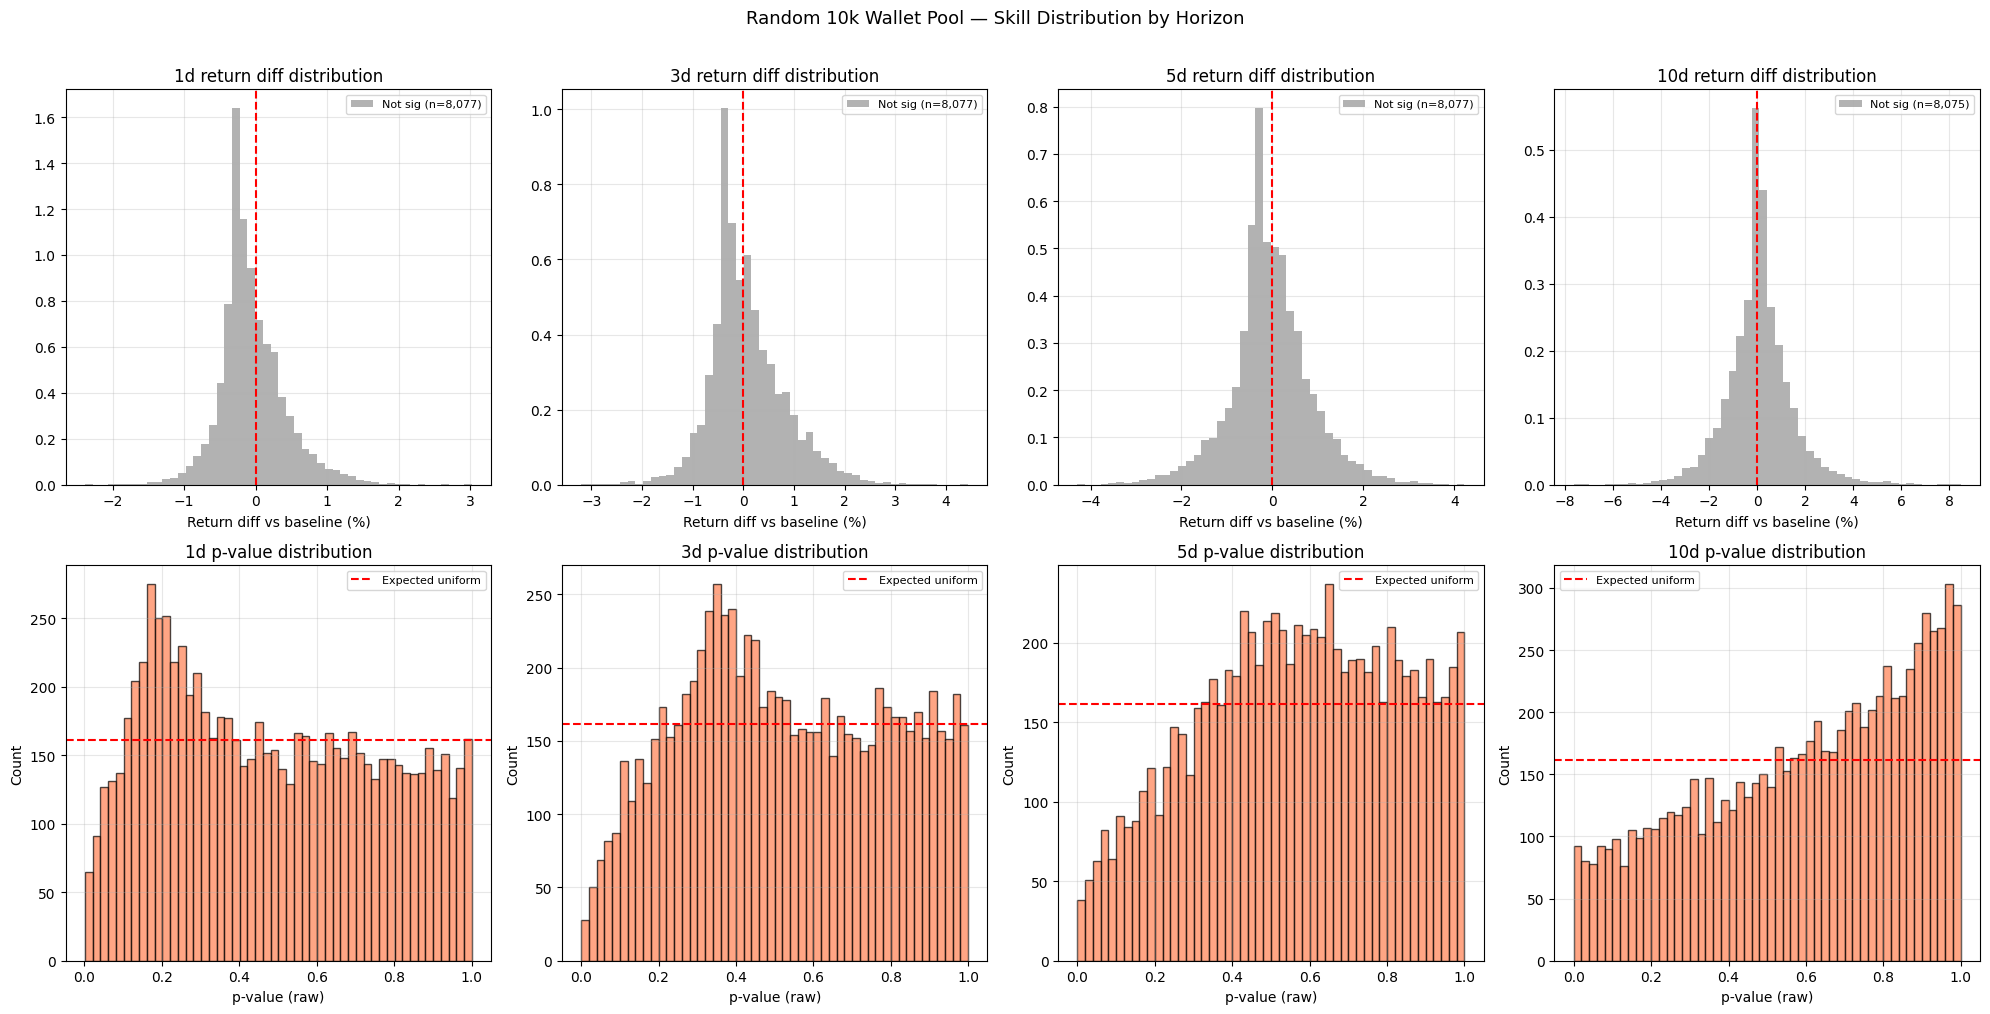

In [16]:
# ============================================================
# Visualize skill distribution across the random wallet pool
# ============================================================

fig, axes = plt.subplots(2, len(HORIZONS), figsize=(20, 10))

for col_idx, h in enumerate(HORIZONS):
    df_h = skill_df[skill_df['horizon']==h].copy()

    # Row 1: Return diff distribution
    ax = axes[0, col_idx]
    sig_fdr  = df_h[df_h['significant_fdr'] & (df_h['return_diff']>0)]['return_diff']
    not_sig  = df_h[~df_h['significant_fdr']]['return_diff']

    ax.hist(not_sig, bins=50, alpha=0.6, color='gray',
            label=f'Not sig (n={len(not_sig):,})', density=True)
    if len(sig_fdr) > 0:
        ax.hist(sig_fdr, bins=20, alpha=0.8, color='steelblue',
                label=f'Sig+positive (n={len(sig_fdr):,})', density=True)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{h}d return diff distribution')
    ax.set_xlabel('Return diff vs baseline (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Row 2: p-value distribution (should be uniform if no signal)
    ax = axes[1, col_idx]
    ax.hist(df_h['p_value_raw'], bins=50, edgecolor='black', color='coral', alpha=0.7)
    ax.axhline(len(df_h)/50, color='red', linewidth=1.5, linestyle='--',
               label='Expected uniform')
    ax.set_title(f'{h}d p-value distribution')
    ax.set_xlabel('p-value (raw)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Random 10k Wallet Pool — Skill Distribution by Horizon', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 11. Top skilled wallets

Detail view of wallets that survive FDR correction with positive return differential.

In [17]:
# ============================================================
# Examine top skilled wallets in detail
# ============================================================

# Best horizon: pick the one with most FDR-significant positive wallets
best_h = (positive_skill.groupby('horizon')['address']
          .nunique().idxmax() if len(positive_skill) > 0 else HORIZONS[0])

print(f"Best horizon (most significant positive wallets): {best_h}d")
print()

top_wallets = (
    skill_df[
        (skill_df['horizon']==best_h) &
        skill_df['significant_fdr'] &
        (skill_df['return_diff']>0)
    ]
    .sort_values('return_diff', ascending=False)
    .head(30)
)

if len(top_wallets) > 0:
    print(f"Top skilled wallets at {best_h}d horizon:")
    print(top_wallets[['address','n_buy_trades','buy_mean_return',
                        'baseline_mean','return_diff','dir_accuracy',
                        'p_value_raw','p_value_fdr']].to_string())
else:
    print("No FDR-significant positive wallets found.")
    print()
    print("Top wallets by raw return diff (uncorrected):")
    top_raw = (
        skill_df[
            (skill_df['horizon']==best_h) &
            skill_df['significant_raw'] &
            (skill_df['return_diff']>0)
        ]
        .sort_values('return_diff', ascending=False)
        .head(20)
    )
    print(top_raw[['address','n_buy_trades','buy_mean_return',
                   'baseline_mean','return_diff','dir_accuracy','p_value_raw']].to_string())


Best horizon (most significant positive wallets): 1d

No FDR-significant positive wallets found.

Top wallets by raw return diff (uncorrected):
                                         address  n_buy_trades  buy_mean_return  baseline_mean  return_diff  dir_accuracy  p_value_raw
5798  0xaed82ac5f043f6e3c70ec0c905031199a2d21d7c            20         3.084758       0.060717     3.024041      0.700000     0.010406
7836  0xf7162b69b5ffadd31a07ea6f0352c64d46dc932e            21         2.742462       0.060717     2.681744      0.714286     0.016519
7845  0xf753befe986e8be8ebe7598c9d2b6297d9dd6662            24         2.717914       0.060717     2.657197      0.791667     0.012799
7852  0xf7aa7ef08a9ccad9b285fa9c13014d4f8d0d1486            21         2.381791       0.060717     2.321073      0.619048     0.043891
7463  0xe9d059bf59bb816206368cc98988c200da7103eb            23         2.119190       0.060717     2.058472      0.826087     0.005431
6156  0xbc02a1c77551cadaacdf9851b0e2efdc3273ea

## 12. Pool-level comparison

Does the random pool collectively beat baseline? Compare to the expert pool results to assess whether convexity selection adds value beyond random sampling.

In [18]:
# ============================================================
# Pool-level significance test on random wallets
# Do they collectively beat baseline? (comparison to expert pool)
# ============================================================

print("=== POOL-LEVEL TEST: RANDOM WALLETS vs EXPERT POOL ===")
print()

buys_all = trade_df[trade_df['action']=='buy']

for h in HORIZONS:
    col = f'fwd_return_{h}d'
    base_ret = trade_df[col].dropna()
    buy_ret  = buys_all[col].dropna()

    t, p = stats.ttest_ind(buy_ret, base_ret)
    diff = buy_ret.mean() - base_ret.mean()
    dir_acc = (buys_all[f'fwd_direction_{h}d'].dropna() > 0).mean()

    print(f"  {h}d: n_buys={len(buy_ret):,}, diff={diff:+.3f}%, "
          f"dir_acc={dir_acc:.3f}, p={p:.4f}")

print()
print("Compare to expert pool (from pool-level tests):")
print("  Buy pool (train): diff ~+0.07%, multiple 1.36x, p≈0")
print("  Buy pool (test):  diff ~+0.07%, multiple 1.38x, p≈0")
print()
print("If random pool shows similar or stronger signal, convexity selection")
print("adds no value. If random pool is weaker/random, selection is validated.")


=== POOL-LEVEL TEST: RANDOM WALLETS vs EXPERT POOL ===

  1d: n_buys=922,753, diff=-0.129%, dir_acc=0.504, p=0.0000
  3d: n_buys=922,753, diff=-0.101%, dir_acc=0.511, p=0.0000
  5d: n_buys=922,753, diff=-0.098%, dir_acc=0.503, p=0.0000
  10d: n_buys=922,753, diff=+0.094%, dir_acc=0.468, p=0.0000

Compare to expert pool (from pool-level tests):
  Buy pool (train): diff ~+0.07%, multiple 1.36x, p≈0
  Buy pool (test):  diff ~+0.07%, multiple 1.38x, p≈0

If random pool shows similar or stronger signal, convexity selection
adds no value. If random pool is weaker/random, selection is validated.


---
## Extension: Top 500 Wallets — Extended History to 2021

Takes the top 500 wallets by raw 1d return differential from the random 10k study and fetches their full history back to January 2021 (~4+ years). More observations per wallet = more statistical power = cleaner signal separation.

**Estimated cost: ~$3.75. Restart-safe.**

### E1. Extended configuration

In [22]:
# ============================================================
# EXTENSION: Top 500 wallets — extended history to 2021
# Appended to random_10k_study.ipynb
# ============================================================

EXTENDED_START_DATE    = date(2021, 1, 1)
EXTENDED_END_DATE      = FETCH_END_DATE   # reuse from main notebook
EXTENDED_BALANCE_CSV   = '/home/colin/projects/blockchain_alpha/data/balance_store_top500_extended.csv'
EXTENDED_SKILL_CSV     = '/home/colin/projects/blockchain_alpha/data/top500_extended_skill_results.csv'
N_TOP_WALLETS          = 500

print(f"Extended window: {EXTENDED_START_DATE} to {EXTENDED_END_DATE}")
print(f"Window length:   {(EXTENDED_END_DATE - EXTENDED_START_DATE).days} days (~{(EXTENDED_END_DATE - EXTENDED_START_DATE).days/365:.1f} years)")

# Cost estimate
n_days = len([d for d in all_dates if d >= EXTENDED_START_DATE])
cost_est = N_TOP_WALLETS * n_days * 19 / 1_000_000 * 0.45
print(f"Estimated cost:  ${cost_est:.2f}")


Extended window: 2021-01-01 to 2026-03-24
Window length:   1908 days (~5.2 years)
Estimated cost:  $3.37


### E2. Select top 500 wallets

In [23]:
# Select top 500 wallets by raw return diff at 1d horizon
# Using skill_df from the main notebook (already computed)

top500_df = (
    skill_df[skill_df['horizon'] == 1]
    .sort_values('return_diff', ascending=False)
    .head(N_TOP_WALLETS)
    .copy()
)

top500_wallets = top500_df['address'].tolist()

print(f"Top {N_TOP_WALLETS} wallets selected by 1d return diff")
print(f"Return diff range: {top500_df['return_diff'].min():.3f}% to {top500_df['return_diff'].max():.3f}%")
print(f"Dir accuracy range: {top500_df['dir_accuracy'].min():.3f} to {top500_df['dir_accuracy'].max():.3f}")
print(f"p-value range: {top500_df['p_value_raw'].min():.4f} to {top500_df['p_value_raw'].max():.4f}")
print()
print("Distribution of return diffs:")
print(top500_df['return_diff'].describe().round(3))


Top 500 wallets selected by 1d return diff
Return diff range: 0.709% to 3.024%
Dir accuracy range: 0.435 to 0.826
p-value range: 0.0017 to 0.5974

Distribution of return diffs:
count    500.000
mean       1.053
std        0.315
min        0.709
25%        0.817
50%        0.971
75%        1.206
max        3.024
Name: return_diff, dtype: float64


### E3. Existence probe — did they exist in 2021?

In [29]:
# Probe: which of the top 500 existed in 2021?
# Only fetch extended history for wallets with non-zero balance at EXTENDED_START_DATE

EXTENDED_PROBE_CSV = '/home/colin/projects/blockchain_alpha/data/top500_existence_probe.csv'

def load_existence_probe(path):
    if not os.path.exists(path):
        return set(), set()  # was: {}, set()
    df = pd.read_csv(path)
    df['address'] = df['address'].str.lower().str.strip()
    qualified = set(df[df['has_balance']==True]['address'].tolist())
    probed    = set(df['address'].tolist())
    return qualified, probed

def save_existence_probe(path, results):
    rows = pd.DataFrame(results)
    if os.path.exists(path):
        rows.to_csv(path, mode='a', header=False, index=False)
    else:
        rows.to_csv(path, index=False)

existing_qualified, already_probed = load_existence_probe(EXTENDED_PROBE_CSV)
remaining = [a for a in top500_wallets if a not in already_probed]

print(f"Already probed: {len(already_probed)}")
print(f"Already qualified: {len(existing_qualified)}")
print(f"Remaining to probe: {len(remaining)}")

if remaining:
    # Get block number for extended start date
    block_2021 = block_map.get(EXTENDED_START_DATE)
    if not block_2021:
        # Build extended block map if needed
        print("Extending block map to cover 2021...")
        block_df_ext = build_or_update_block_map(
            start_date=str(EXTENDED_START_DATE),
            end_date=str(EXTENDED_END_DATE),
            period="day",
            etherscan_api_key=ETHERSCAN_API_KEY,
            existing_csv_path=EXISTING_BLOCK_MAP_CSV,
            sleep_sec=0.51,
            write_back=True
        )
        block_map.update(dict(zip(block_df_ext['timestamp'], block_df_ext['block_number'])))
        block_2021 = block_map.get(EXTENDED_START_DATE)

    assert block_2021, f"No block found for {EXTENDED_START_DATE}"
    print(f"Block at {EXTENDED_START_DATE}: {block_2021:,}")

    new_qualified = get_addresses_with_nonzero_balance(
        addresses=remaining,
        block_number=block_2021,
        alchemy_api_key=ALCHEMY_API_KEY,
        max_addresses=len(remaining)
    )

    batch = [
        {'address': a, 'has_balance': a in set(new_qualified)}
        for a in remaining
    ]
    save_existence_probe(EXTENDED_PROBE_CSV, batch)
    existing_qualified.update(a.lower().strip() for a in new_qualified)
    print(f"New qualified (existed in 2021): {len(new_qualified)}")

extended_wallets = sorted(existing_qualified)
print()
print(f"Wallets with history back to {EXTENDED_START_DATE}: {len(extended_wallets)} of {N_TOP_WALLETS}")
print(f"Wallets that didn't exist in 2021: {N_TOP_WALLETS - len(extended_wallets)}")
print(f"Will fetch from their earliest available date instead")


Already probed: 500
Already qualified: 59
Remaining to probe: 0

Wallets with history back to 2021-01-01: 59 of 500
Wallets that didn't exist in 2021: 441
Will fetch from their earliest available date instead


### E4. Extended history fetch (restart-safe)

Fetches pre-2024 dates only — post-2024 data already exists in the random_10k store. Saves to `balance_store_top500_extended.csv`.

In [30]:
# Re-probe the 441 wallets that didn't exist in 2021
# Check for existence at 2023-01-01 instead
FALLBACK_DATE = date(2023, 1, 1)

fallback_wallets = [a for a in top500_wallets 
                    if a not in wallets_from_2021]

print(f"Re-probing {len(fallback_wallets)} wallets at {FALLBACK_DATE}...")

FALLBACK_PROBE_CSV = '/home/colin/projects/blockchain_alpha/data/top500_fallback_probe.csv'

fallback_qualified, fallback_probed = load_existence_probe(FALLBACK_PROBE_CSV)
remaining_fallback = [a for a in fallback_wallets if a not in fallback_probed]
print(f"Already probed: {len(fallback_probed)}, remaining: {len(remaining_fallback)}")

if remaining_fallback:
    block_2023 = block_map.get(FALLBACK_DATE)
    if not block_2023:
        print("Extending block map to cover 2023...")
        block_df_ext2 = build_or_update_block_map(
            start_date=str(FALLBACK_DATE),
            end_date=str(EXTENDED_END_DATE),
            period="day",
            etherscan_api_key=ETHERSCAN_API_KEY,
            existing_csv_path=EXISTING_BLOCK_MAP_CSV,
            sleep_sec=0.51,
            write_back=True
        )
        block_map.update(dict(zip(block_df_ext2['timestamp'], 
                                   block_df_ext2['block_number'])))
        block_2023 = block_map.get(FALLBACK_DATE)

    assert block_2023, f"No block found for {FALLBACK_DATE}"

    new_fallback = get_addresses_with_nonzero_balance(
        addresses=remaining_fallback,
        block_number=block_2023,
        alchemy_api_key=ALCHEMY_API_KEY,
        max_addresses=len(remaining_fallback)
    )

    batch = [{'address': a, 'has_balance': a in set(new_fallback)}
             for a in remaining_fallback]
    save_existence_probe(FALLBACK_PROBE_CSV, batch)
    fallback_qualified.update(a.lower().strip() for a in new_fallback)

wallets_from_2023 = sorted(fallback_qualified)
print(f"Wallets with history back to {FALLBACK_DATE}: {len(wallets_from_2023)} of {len(fallback_wallets)}")

# Update the fetch targets
# wallets_from_2021: fetch from 2021-01-01
# wallets_from_2023: fetch from 2023-01-01  
# remaining: use existing 2.5yr data only
wallets_existing_only = set(top500_wallets) - set(wallets_from_2021) - set(wallets_from_2023)
print(f"\nFetch plan:")
print(f"  From 2021: {len(wallets_from_2021)} wallets")
print(f"  From 2023: {len(wallets_from_2023)} wallets")  
print(f"  Existing 2.5yr only: {len(wallets_existing_only)} wallets")

Re-probing 441 wallets at 2023-01-01...
Already probed: 441, remaining: 0
Wallets with history back to 2023-01-01: 246 of 441

Fetch plan:
  From 2021: 59 wallets
  From 2023: 246 wallets
  Existing 2.5yr only: 195 wallets


In [31]:
# ============================================================
# E4b: Extended history fetch — three tiers
# Tier 1 (59 wallets): fetch from 2021-01-01
# Tier 2 (246 wallets): fetch from 2023-01-01
# Tier 3 (195 wallets): no new fetch needed
# ============================================================

# Build full extended date list
df_price_ext_dates = load_eth_usd_yahoo(start="2020-01-01")
df_price_ext_dates['date'] = pd.to_datetime(df_price_ext_dates['date'])
extended_dates = sorted(
    df_price_ext_dates.loc[
        (df_price_ext_dates['date'].dt.date >= EXTENDED_START_DATE) &
        (df_price_ext_dates['date'].dt.date <= EXTENDED_END_DATE),
        'date'
    ].dt.date.tolist()
)
extended_dates = [d for d in extended_dates if d in block_map]

# Load already-fetched pairs
print("Loading already-fetched pairs...")
already_fetched_10k = load_fetched_pairs(BALANCE_STORE_CSV)
already_fetched_ext = load_fetched_pairs(EXTENDED_BALANCE_CSV)
all_already_fetched = already_fetched_10k | already_fetched_ext
print(f"  Combined already-fetched: {len(all_already_fetched):,} pairs")
print()

FETCH_PLAN = [
    (sorted(wallets_from_2021), EXTENDED_START_DATE),
    (sorted(wallets_from_2023), FALLBACK_DATE),
]

for tier_wallets, tier_start in FETCH_PLAN:
    if not tier_wallets:
        continue

    # Only fetch the gap — dates before existing data starts
    tier_dates = sorted([
        d for d in extended_dates
        if d >= tier_start and d < HISTORY_START_DATE
        and d in block_map
    ])

    if not tier_dates:
        print(f"No new dates to fetch for {tier_start} tier — skipping")
        continue

    n_pairs = len(tier_wallets) * len(tier_dates)
    cost    = n_pairs * 19 / 1_000_000 * 0.45
    print(f"Fetching {tier_start} tier: {len(tier_wallets)} wallets × "
          f"{len(tier_dates)} dates = {n_pairs:,} pairs (~${cost:.2f})")

    fetch_count = 0
    for i, event_date in enumerate(tier_dates):
        event_ts       = pd.Timestamp(event_date).normalize()
        event_date_str = str(event_date)

        sched_day = pd.DataFrame({
            'address': tier_wallets,
            'date':    event_ts
        })
        sched_day['date']    = pd.to_datetime(sched_day['date']).dt.normalize()
        sched_day['address'] = sched_day['address'].str.lower().str.strip()

        mask = sched_day.apply(
            lambda r: (r['address'], r['date']) not in all_already_fetched,
            axis=1
        )
        sched_new = sched_day[mask].reset_index(drop=True)

        if not sched_new.empty:
            bal = fetch_balances_for_schedule(
                schedule=sched_new,
                block_df=block_df,
                alchemy_api_key=ALCHEMY_API_KEY,
                batch_size=100,
                max_concurrency=30,
                rps=25.0,
                progress_every=500,
                block_date_col="timestamp",
                label=f"ext-{tier_start.year}-{event_date_str}"
            )

            if not bal.empty:
                if os.path.exists(EXTENDED_BALANCE_CSV):
                    bal.to_csv(EXTENDED_BALANCE_CSV, mode='a', header=False, index=False)
                else:
                    bal.to_csv(EXTENDED_BALANCE_CSV, index=False)

                bal['date_norm'] = pd.to_datetime(
                    bal['date'], format='mixed').dt.normalize()
                newly = set(zip(
                    bal['address'].str.lower().str.strip(),
                    bal['date_norm']
                ))
                all_already_fetched.update(newly)
                fetch_count += len(bal)

        if (i + 1) % 30 == 0 or (i + 1) == len(tier_dates):
            print(f"  [{i+1}/{len(tier_dates)}] {event_date_str} — "
                  f"{fetch_count:,} rows fetched this tier")

    print(f"Tier {tier_start} complete. {fetch_count:,} new rows.\n")

print("All extended fetches complete.")
print(f"Tier 3 ({len(wallets_existing_only)} wallets): using existing 2.5yr data — no fetch needed.")

Loading already-fetched pairs...
  Combined already-fetched: 7,904,072 pairs

Fetching 2021-01-01 tier: 59 wallets × 1060 dates = 62,540 pairs (~$0.53)
  [30/1060] 2021-01-31 — 0 rows fetched this tier
  [60/1060] 2021-03-03 — 0 rows fetched this tier
  [90/1060] 2021-04-03 — 0 rows fetched this tier
  [120/1060] 2021-05-04 — 0 rows fetched this tier
  [150/1060] 2021-06-04 — 0 rows fetched this tier
  [180/1060] 2021-07-05 — 0 rows fetched this tier
  [210/1060] 2021-08-05 — 0 rows fetched this tier
  [240/1060] 2021-09-05 — 0 rows fetched this tier
  [270/1060] 2021-10-06 — 0 rows fetched this tier
  [300/1060] 2021-11-06 — 0 rows fetched this tier
  [330/1060] 2021-12-07 — 0 rows fetched this tier
  [360/1060] 2022-01-07 — 0 rows fetched this tier
  [390/1060] 2022-02-07 — 0 rows fetched this tier
[ext-2021-2022-02-27] 1/1 batches (100.0%)
[ext-2021-2022-02-28] 1/1 batches (100.0%)
[ext-2021-2022-03-01] 1/1 batches (100.0%)
[ext-2021-2022-03-02] 1/1 batches (100.0%)
[ext-2021-2022-0

In [32]:
# ============================================================
# EXTENSION: Top 500 wallets — extended history to 2021
# Appended to random_10k_study.ipynb
# ============================================================

EXTENDED_START_DATE    = date(2021, 1, 1)
EXTENDED_END_DATE      = FETCH_END_DATE   # reuse from main notebook
EXTENDED_BALANCE_CSV   = '/home/colin/projects/blockchain_alpha/data/balance_store_top500_extended.csv'
EXTENDED_SKILL_CSV     = '/home/colin/projects/blockchain_alpha/data/top500_extended_skill_results.csv'
N_TOP_WALLETS          = 500

print(f"Extended window: {EXTENDED_START_DATE} to {EXTENDED_END_DATE}")
print(f"Window length:   {(EXTENDED_END_DATE - EXTENDED_START_DATE).days} days (~{(EXTENDED_END_DATE - EXTENDED_START_DATE).days/365:.1f} years)")

# Cost estimate
n_days = len([d for d in all_dates if d >= EXTENDED_START_DATE])
cost_est = N_TOP_WALLETS * n_days * 19 / 1_000_000 * 0.45
print(f"Estimated cost:  ${cost_est:.2f}")


Extended window: 2021-01-01 to 2026-03-24
Window length:   1908 days (~5.2 years)
Estimated cost:  $3.37


In [33]:
print(f"wallets_from_2021: {len(wallets_from_2021)}")
print(f"wallets_from_2023: {len(wallets_from_2023)}")
print(f"wallets_existing_only: {len(wallets_existing_only)}")
print(f"top500_wallets: {len(top500_wallets)}")
print(f"EXTENDED_BALANCE_CSV exists: {os.path.exists(EXTENDED_BALANCE_CSV)}")

wallets_from_2021: 59
wallets_from_2023: 246
wallets_existing_only: 195
top500_wallets: 500
EXTENDED_BALANCE_CSV exists: True


### E5. Merge extended + existing data, infer actions

In [34]:
# ============================================================
# Merge extended + existing data, recompute skill scores
# ============================================================

print("Loading and merging balance data...")

# Load extended store (pre-2024 data)
if os.path.exists(EXTENDED_BALANCE_CSV):
    ext_raw = pd.read_csv(EXTENDED_BALANCE_CSV)
    ext_raw['date']        = pd.to_datetime(ext_raw['date'], format='mixed').dt.normalize()
    ext_raw['address']     = ext_raw['address'].str.lower().str.strip()
    ext_raw['balance_wei'] = pd.to_numeric(ext_raw['balance_wei'], errors='coerce').fillna(0).astype('int64')
    print(f"Extended store (pre-2024): {len(ext_raw):,} rows")
else:
    ext_raw = pd.DataFrame()
    print("No extended store found — using existing data only")

# Load existing random_10k store (post-2024 data) for top 500 wallets only
existing_raw = pd.read_csv(BALANCE_STORE_CSV)
existing_raw['date']    = pd.to_datetime(existing_raw['date'], format='mixed').dt.normalize()
existing_raw['address'] = existing_raw['address'].str.lower().str.strip()
existing_raw['balance_wei'] = pd.to_numeric(existing_raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

# Filter to top 500 only
top500_set = set(a.lower().strip() for a in top500_wallets)
existing_filtered = existing_raw[existing_raw['address'].isin(top500_set)].copy()
print(f"Existing store (post-2024, top500 only): {len(existing_filtered):,} rows")

# Combine
if not ext_raw.empty:
    combined_raw = pd.concat([ext_raw, existing_filtered], ignore_index=True)
else:
    combined_raw = existing_filtered.copy()

# Deduplicate
combined = (
    combined_raw
    .sort_values(['address', 'date', 'block_number'])
    .groupby(['address', 'date'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
combined['balance_eth'] = pd.to_numeric(combined['balance_wei'], errors='coerce') / 1e18

print(f"Combined deduplicated: {len(combined):,} rows")
print(f"Unique addresses: {combined['address'].nunique():,}")
print(f"Date range: {combined['date'].min().date()} to {combined['date'].max().date()}")

# Infer actions
combined = combined.sort_values(['address', 'date'])
combined['delta_eth'] = combined.groupby('address')['balance_eth'].diff()
combined['action'] = combined['delta_eth'].apply(classify_action)
actions_ext = combined.dropna(subset=['action']).copy()

print(f"\nAction observations: {len(actions_ext):,}")
print(actions_ext['action'].value_counts())

# Per-wallet trade count summary
trade_counts_ext = actions_ext[actions_ext['action']=='buy'].groupby('address').size()
print(f"\nBuy trade count distribution (extended window):")
print(trade_counts_ext.describe().round(1))
print(f"Wallets with >= 20 buy trades: {(trade_counts_ext >= 20).sum()}")
print(f"Wallets with >= 50 buy trades: {(trade_counts_ext >= 50).sum()}")
print(f"Wallets with >= 100 buy trades: {(trade_counts_ext >= 100).sum()}")


Loading and merging balance data...
Extended store (pre-2024): 149,378 rows


/tmp/ipykernel_5102/3210814144.py:19: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_raw = pd.read_csv(BALANCE_STORE_CSV)


Existing store (post-2024, top500 only): 394,000 rows
Combined deduplicated: 543,378 rows
Unique addresses: 500
Date range: 2021-01-01 to 2026-03-24

Action observations: 542,878
action
hold    492408
sell     25879
buy      24591
Name: count, dtype: int64

Buy trade count distribution (extended window):
count    500.0
mean      49.2
std       30.1
min       20.0
25%       30.0
50%       44.0
75%       54.2
max      298.0
dtype: float64
Wallets with >= 20 buy trades: 500
Wallets with >= 50 buy trades: 176
Wallets with >= 100 buy trades: 30


### E6. Recompute skill scores on extended window

In [36]:
TRAIN_START_DATE = date(2024, 3, 1)

In [39]:
# ============================================================
# Recompute forward return skill on extended dataset
# ============================================================

# Merge forward returns
df_price_ext = df_price_full2.copy()
for h in HORIZONS:
    df_price_ext[f'fwd_return_{h}d']    = (
        df_price_ext['close'].shift(-h) - df_price_ext['close']
    ) / df_price_ext['close'] * 100
    df_price_ext[f'fwd_direction_{h}d'] = np.sign(df_price_ext[f'fwd_return_{h}d'])

df_price_ext['period'] = df_price_ext['date'].apply(
    lambda d: 'pre_train' if d.date() < TRAIN_START_DATE
              else ('train' if d.date() < TRAIN_END_DATE
              else ('test' if d.date() <= EXTENDED_END_DATE else 'future'))
)

trade_ext = actions_ext.merge(
    df_price_ext[['date','period'] +
                  [f'fwd_return_{h}d' for h in HORIZONS] +
                  [f'fwd_direction_{h}d' for h in HORIZONS]],
    on='date', how='inner'
)

# Filter to >= 20 buy trades
active_ext = trade_counts_ext[trade_counts_ext >= 20].index.tolist()
trade_ext  = trade_ext[trade_ext['address'].isin(active_ext)].copy()

print(f"Trade observations (extended, active wallets): {len(trade_ext):,}")
print(f"Active wallets: {trade_ext['address'].nunique():,}")
print()

# Vectorized skill scoring
print("Computing extended skill scores...")
skill_rows_ext = []

buys_ext  = trade_ext[trade_ext['action']=='buy'].copy()
sells_ext = trade_ext[trade_ext['action']=='sell'].copy()
buy_grps  = buys_ext.groupby('address')

for h in HORIZONS:
    col     = f'fwd_return_{h}d'
    dir_col = f'fwd_direction_{h}d'

    base_mean = trade_ext[col].mean()
    base_std  = trade_ext[col].std()
    base_n    = trade_ext[col].notna().sum()
    base_dir  = (trade_ext[dir_col].dropna() > 0).mean()

    print(f"  {h}d horizon...")

    for addr in active_ext:
        if addr not in buy_grps.groups:
            continue
        buy_ret = buy_grps.get_group(addr)[col].dropna()
        if len(buy_ret) < 10:
            continue

        buy_mean = buy_ret.mean()
        buy_std  = buy_ret.std()
        buy_n    = len(buy_ret)

        se = np.sqrt(buy_std**2/buy_n + base_std**2/base_n)
        if se == 0:
            p_val = 1.0
        else:
            t_stat = (buy_mean - base_mean) / se
            df_w   = (buy_std**2/buy_n + base_std**2/base_n)**2 /                      ((buy_std**2/buy_n)**2/(buy_n-1) + (base_std**2/base_n)**2/(base_n-1))
            p_val  = 2 * stats.t.sf(abs(t_stat), df=df_w)

        buy_dir_acc = (buy_grps.get_group(addr)[dir_col].dropna() > 0).mean()

        n_sell = len(sells_ext[sells_ext['address']==addr]) if addr in sells_ext['address'].values else 0

        skill_rows_ext.append({
            'address':        addr,
            'horizon':        h,
            'n_buy_trades':   buy_n,
            'n_sell_trades':  n_sell,
            'buy_mean_return':buy_mean,
            'baseline_mean':  base_mean,
            'return_diff':    buy_mean - base_mean,
            'dir_accuracy':   buy_dir_acc,
            'baseline_dir':   base_dir,
            'p_value_raw':    p_val,
        })

skill_ext_df = pd.DataFrame(skill_rows_ext)

# FDR correction
print("\nApplying FDR correction...")
for h in HORIZONS:
    mask   = skill_ext_df['horizon'] == h
    pvals  = skill_ext_df.loc[mask, 'p_value_raw'].values
    reject, pvals_fdr, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method='fdr_bh')
    skill_ext_df.loc[mask, 'p_value_fdr']     = pvals_fdr
    skill_ext_df.loc[mask, 'significant_fdr'] = reject.astype(bool)
    skill_ext_df.loc[mask, 'significant_raw'] = (pvals < 0.05)

    n_sig = reject.sum()
    n_raw = (pvals < 0.05).sum()
    n_tot = mask.sum()
    print(f"  {h}d: {n_sig} FDR-significant, {n_raw} uncorrected p<0.05 (of {n_tot} wallets)")

positive_ext = skill_ext_df[
    skill_ext_df['significant_fdr'] & (skill_ext_df['return_diff'] > 0)
]
print(f"\nFDR-significant positive wallets (any horizon): {positive_ext['address'].nunique()}")


Trade observations (extended, active wallets): 542,878
Active wallets: 500

Computing extended skill scores...
  1d horizon...
  3d horizon...
  5d horizon...
  10d horizon...

Applying FDR correction...
  1d: 0 FDR-significant, 61 uncorrected p<0.05 (of 500 wallets)
  3d: 0 FDR-significant, 29 uncorrected p<0.05 (of 500 wallets)
  5d: 0 FDR-significant, 18 uncorrected p<0.05 (of 500 wallets)
  10d: 1 FDR-significant, 26 uncorrected p<0.05 (of 500 wallets)

FDR-significant positive wallets (any horizon): 1


### E7. Results — tiering and comparison to 2.5yr window

Key question: do the top wallets' signals strengthen or weaken with more data? Strengthening = genuine skill. Weakening = lucky over 2.5 years.

In [40]:
# ============================================================
# Extended results: top wallets and tiering
# ============================================================

best_h_ext = 1  # use 1d as primary horizon

# Full ranking at 1d horizon
ranking_1d = (
    skill_ext_df[skill_ext_df['horizon']==best_h_ext]
    .sort_values('return_diff', ascending=False)
    .copy()
)

print(f"=== TOP 30 WALLETS — EXTENDED WINDOW ({best_h_ext}d horizon) ===")
print(ranking_1d[['address','n_buy_trades','buy_mean_return','baseline_mean',
                   'return_diff','dir_accuracy','p_value_raw','p_value_fdr',
                   'significant_fdr']].head(30).to_string())
print()

# Tiering
tier1 = ranking_1d[ranking_1d['significant_fdr'] & (ranking_1d['return_diff']>0)]
tier2 = ranking_1d[
    ~ranking_1d['significant_fdr'] &
    (ranking_1d['p_value_raw'] < 0.05) &
    (ranking_1d['return_diff'] > 0)
]
tier3 = ranking_1d[
    ~ranking_1d['significant_fdr'] &
    (ranking_1d['p_value_raw'] >= 0.05)
]

print(f"Tier 1 — FDR-significant positive skill: {len(tier1)} wallets")
print(f"Tier 2 — Uncorrected significant, positive: {len(tier2)} wallets")
print(f"Tier 3 — Not significant: {len(tier3)} wallets")
print()

# Compare to original 2.5-year results
orig_top = skill_df[skill_df['horizon']==best_h_ext].sort_values('return_diff', ascending=False).head(500)
compare = orig_top[['address','return_diff','p_value_raw']].merge(
    ranking_1d[['address','return_diff','n_buy_trades','p_value_raw','significant_fdr']],
    on='address', how='left', suffixes=('_2.5yr','_extended')
)

print("=== COMPARISON: 2.5yr vs extended window for top 30 ===")
print(compare[['address','return_diff_2.5yr','return_diff_extended',
               'n_buy_trades','p_value_raw_2.5yr','p_value_raw_extended',
               'significant_fdr']].head(30).to_string())
print()
print("Wallets whose signal STRENGTHENED with more data:")
strengthened = compare[
    (compare['return_diff_extended'] > compare['return_diff_2.5yr']) &
    (compare['return_diff_extended'] > 0)
]
print(f"  {len(strengthened)} wallets")
print()
print("Wallets whose signal WEAKENED with more data (likely lucky over 2.5yr):")
weakened = compare[
    (compare['return_diff_extended'] < compare['return_diff_2.5yr'] * 0.5) |
    (compare['return_diff_extended'] < 0)
]
print(f"  {len(weakened)} wallets")


=== TOP 30 WALLETS — EXTENDED WINDOW (1d horizon) ===
                                        address  n_buy_trades  buy_mean_return  baseline_mean  return_diff  dir_accuracy  p_value_raw  p_value_fdr significant_fdr
119  0xaed82ac5f043f6e3c70ec0c905031199a2d21d7c            20         3.084758       0.102575     2.982183      0.700000     0.011340     0.341117           False
290  0xe9d059bf59bb816206368cc98988c200da7103eb            23         2.119190       0.102575     2.016614      0.826087     0.006285     0.341117           False
146  0xbc02a1c77551cadaacdf9851b0e2efdc3273eace            36         2.086778       0.102575     1.984203      0.694444     0.002089     0.341117           False
0    0x01f06d1200782e5bbe5fd134ce0ca3fe0c86d854            29         2.013087       0.102575     1.910511      0.758621     0.011078     0.341117           False
322  0xeb350b745ca6f09e4c44b8130900f42351832d37            26         1.964377       0.102575     1.861801      0.730769     0.0055

In [41]:
# Find the 10d FDR survivor
survivor = skill_ext_df[
    (skill_ext_df['horizon'] == 10) &
    skill_ext_df['significant_fdr'] &
    (skill_ext_df['return_diff'] > 0)
]
print(survivor[['address','n_buy_trades','buy_mean_return','baseline_mean',
                'return_diff','dir_accuracy','p_value_raw','p_value_fdr']].to_string())

                                         address  n_buy_trades  buy_mean_return  baseline_mean  return_diff  dir_accuracy  p_value_raw  p_value_fdr
1507  0x1b4b91bb747176451f0f7f73b636babafcf31cc4           148         4.131225       0.886105     3.245119      0.682432      0.00005     0.025024


In [42]:
# 1. Full profile of this wallet
wallet_addr = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

# When did it trade? What's its activity pattern?
wallet_trades = trade_ext[
    (trade_ext['address'] == wallet_addr) &
    (trade_ext['action'] == 'buy')
].sort_values('date')

print(f"First buy: {wallet_trades['date'].min().date()}")
print(f"Last buy:  {wallet_trades['date'].max().date()}")
print(f"Active months: {(wallet_trades['date'].max() - wallet_trades['date'].min()).days / 30:.1f}")
print()

# 2. Is the signal consistent across the full window or clustered in a period?
wallet_trades['year_month'] = wallet_trades['date'].dt.to_period('M')
monthly = wallet_trades.groupby('year_month')['fwd_return_1d'].agg(['mean','count'])
print("Monthly buy activity and returns:")
print(monthly.to_string())
print()

# 3. Check all horizons for this wallet
for h in HORIZONS:
    row = skill_ext_df[
        (skill_ext_df['address'] == wallet_addr) &
        (skill_ext_df['horizon'] == h)
    ].iloc[0]
    print(f"{h}d: diff={row['return_diff']:+.3f}%, dir_acc={row['dir_accuracy']:.3f}, "
          f"p_raw={row['p_value_raw']:.5f}, p_fdr={row['p_value_fdr']:.5f}, "
          f"sig={row['significant_fdr']}")

First buy: 2023-01-05
Last buy:  2026-03-13
Active months: 38.8

Monthly buy activity and returns:
                mean  count
year_month                 
2023-01     0.204178      9
2023-02     0.311602      7
2023-03     0.890738      8
2023-04    -0.890473      5
2023-05     0.835521      8
2023-06     1.289711      3
2023-07    -0.028372      4
2023-08     1.089029      3
2023-09    -0.353541      3
2023-10     0.942907      9
2023-11    -0.476786      8
2023-12     0.618642      8
2024-01    -0.866648      3
2024-02     1.345676      9
2024-03     5.219828      6
2024-04    -1.073668      2
2024-05    -0.635949      4
2024-06    -1.999510      1
2024-08    -2.434282      1
2024-09    -0.795801      2
2024-11     3.261531      7
2024-12     4.126350      2
2025-03    -1.767096      3
2025-04    -0.586198      2
2025-05     0.392914      3
2025-07     0.214120      4
2025-09     0.496995      2
2025-11    -3.199131      1
2025-12     0.856279      7
2026-01     0.224272      4
2026-

# Spent about $120 to find one good, statistically consistent valid wallet.  This POC is real, but we need a more efficient search strategy.  her4e is the wallet details and full history:

In [43]:
# How far back does this wallet go?
# Check Alchemy for earliest transaction
wallet_addr = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

# Also check its sell behavior
sell_profile = skill_ext_df[
    (skill_ext_df['address'] == wallet_addr)
].copy()

# And look at the actual buy dates vs ETH price
wallet_buys = trade_ext[
    (trade_ext['address'] == wallet_addr) &
    (trade_ext['action'] == 'buy')
][['date', 'delta_eth', 'fwd_return_1d', 'fwd_return_10d']].sort_values('date')

print("Buy profile:")
print(wallet_buys.to_string())

Buy profile:
           date  delta_eth  fwd_return_1d  fwd_return_10d
7276 2023-01-05   0.011718       1.514703       24.154796
7278 2023-01-07   0.012353       1.826280       24.011927
7280 2023-01-09   0.006533       1.138606       17.480951
7284 2023-01-13   0.016019       6.826331       12.168257
7287 2023-01-16   0.021587      -0.569967        1.666153
7291 2023-01-20   0.021493      -1.966314       -5.568753
7296 2023-01-25   0.012817      -0.533911        3.434123
7298 2023-01-27   0.011556      -1.609444        4.620764
7300 2023-01-29   0.029752      -4.788679       -6.057593
7304 2023-02-02   0.009056       1.308635       -8.280930
7305 2023-02-03   0.276462       0.138976       -6.479698
7308 2023-02-07   0.017494      -1.273128        1.362424
7310 2023-02-09   0.011216      -2.041407        8.729603
7314 2023-02-13   0.015099       3.298192        9.548249
7317 2023-02-16   0.012572       3.336185        0.045700
7324 2023-02-23   0.083964      -2.586237       -5.245380
7

In [44]:
# Define high-conviction signal threshold
HIGH_CONVICTION_THRESHOLD = 1.0  # ETH

# Filter to high-conviction buys only
high_conviction = wallet_buys[wallet_buys['delta_eth'] >= HIGH_CONVICTION_THRESHOLD]

print(f"High conviction trades: {len(high_conviction)}")
print(f"Mean 1d return: {high_conviction['fwd_return_1d'].mean():.3f}%")
print(f"Mean 10d return: {high_conviction['fwd_return_10d'].mean():.3f}%")
print(f"Dir accuracy 10d: {(high_conviction['fwd_return_10d'] > 0).mean():.3f}")
print()
print(high_conviction[['date','delta_eth','fwd_return_1d','fwd_return_10d']].to_string())

High conviction trades: 24
Mean 1d return: 1.058%
Mean 10d return: 7.767%
Dir accuracy 10d: 0.917

           date  delta_eth  fwd_return_1d  fwd_return_10d
7343 2023-03-15   2.229986       1.270086        5.288326
7374 2023-04-16   1.090345      -2.064284      -11.954762
7404 2023-05-17   1.847724      -1.104976        0.508199
7406 2023-05-19   1.028754       0.435209        4.440534
7409 2023-05-22   3.576325       2.027242        2.457539
7549 2023-10-14   3.166627       0.180870       14.735872
7550 2023-10-15   1.484969       2.725454       14.718709
7556 2023-10-21   1.146581       2.094482       11.486775
7562 2023-10-27   7.894126      -0.192530        6.729723
7564 2023-10-29   4.259128       0.809926        5.222721
7566 2023-10-31   3.175135       1.686288       14.414353
7567 2023-11-01   2.450998      -2.515782       11.132331
7578 2023-11-12   4.220502       0.492785        0.832378
7581 2023-11-16   3.407572       0.020357        5.222373
7612 2023-12-18   7.183535     

In [45]:
# Check most recent activity
print("Most recent trades:")
print(wallet_buys.tail(10)[['date','delta_eth','fwd_return_1d']].to_string())

# Is it still active?
last_trade = wallet_buys['date'].max()
days_since = (pd.Timestamp.today() - last_trade).days
print(f"\nDays since last buy: {days_since}")

Most recent trades:
           date  delta_eth  fwd_return_1d
8369 2026-02-06   0.010024       1.316396
8371 2026-02-08   0.010024       0.708778
8373 2026-02-10   0.010024      -3.592813
8375 2026-02-13   0.007001       1.829725
8383 2026-02-21   0.010001      -0.807163
8392 2026-03-02   0.006012      -2.195071
8394 2026-03-04   0.009001      -2.581696
8396 2026-03-06   0.009001      -0.469780
8399 2026-03-09   0.005332       2.216940
8402 2026-03-13   0.005332       0.216156

Days since last buy: 33


In [46]:
wallet_sells = trade_ext[
    (trade_ext['address'] == wallet_addr) &
    (trade_ext['action'] == 'sell')
][['date','delta_eth','fwd_return_1d','fwd_return_10d']].sort_values('date')

high_conv_sells = wallet_sells[wallet_sells['delta_eth'].abs() >= 1.0]
print(f"High conviction sells: {len(high_conv_sells)}")
if len(high_conv_sells) > 0:
    print(f"Mean 10d return after sell: {high_conv_sells['fwd_return_10d'].mean():.3f}%")
    print(f"Dir accuracy (negative return = good sell): {(high_conv_sells['fwd_return_10d'] < 0).mean():.3f}")
    print(high_conv_sells[['date','delta_eth','fwd_return_10d']].to_string())

High conviction sells: 23
Mean 10d return after sell: 8.021%
Dir accuracy (negative return = good sell): 0.174
           date  delta_eth  fwd_return_10d
7344 2023-03-16  -2.231671        5.870522
7375 2023-04-17  -1.102468       -8.065364
7405 2023-05-18  -1.398919        6.060051
7408 2023-05-21  -1.601010        3.856908
7410 2023-05-23  -3.514957        2.851409
7552 2023-10-17  -1.139850       13.708975
7553 2023-10-18  -2.815393       13.612681
7557 2023-10-22  -1.150691       11.041030
7563 2023-10-28  -7.894928        6.276312
7565 2023-10-30  -4.247136       17.152332
7568 2023-11-02  -5.637399       13.582317
7579 2023-11-13  -4.301304        1.259532
7582 2023-11-17  -3.431970        3.372113
7614 2023-12-20  -5.221096        4.094354
7616 2023-12-22  -6.388335        1.109078
7925 2024-11-05  -9.223372       28.084524
7927 2024-11-07  -9.223372        6.218990
7929 2024-11-09  -9.223372       -0.631095
7931 2024-11-11  -9.223372       -0.407698
7933 2024-11-13  -9.223372   

# Size weighted analysis:

In [47]:
import numpy as np

wallet_addr = '0x1b4b91bb747176451f0f7f73b636babafcf31cc4'

wallet_buys = trade_ext[
    (trade_ext['address'] == wallet_addr) &
    (trade_ext['action'] == 'buy')
].copy()

# Baseline: size-weighted returns for ALL wallets combined
# (what you'd get from random size-weighted buying)
all_buys = trade_ext[trade_ext['action'] == 'buy'].copy()

print("=== SIZE-WEIGHTED RETURN ANALYSIS ===")
print(f"Wallet: {wallet_addr}")
print(f"Total buys: {len(wallet_buys)}, Total ETH deployed: {wallet_buys['delta_eth'].sum():.2f}")
print()

for h in HORIZONS:
    col     = f'fwd_return_{h}d'
    dir_col = f'fwd_direction_{h}d'

    # Wallet metrics
    valid_w = wallet_buys[['delta_eth', col, dir_col]].dropna()
    unwtd_mean    = valid_w[col].mean()
    wtd_mean      = np.average(valid_w[col],               weights=valid_w['delta_eth'])
    dir_acc_unwtd = (valid_w[col] > 0).mean()
    dir_acc_wtd   = np.average((valid_w[col] > 0).astype(float), weights=valid_w['delta_eth'])

    # Baseline metrics (population size-weighted)
    valid_b = all_buys[['delta_eth', col]].dropna()
    base_unwtd = valid_b[col].mean()
    base_wtd   = np.average(valid_b[col], weights=valid_b['delta_eth'])

    # Differential
    diff_unwtd = unwtd_mean - base_unwtd
    diff_wtd   = wtd_mean   - base_wtd

    print(f"{h}d horizon:")
    print(f"  Unweighted:    wallet={unwtd_mean:+.3f}%  baseline={base_unwtd:+.3f}%  diff={diff_unwtd:+.3f}%  dir_acc={dir_acc_unwtd:.3f}")
    print(f"  Size-weighted: wallet={wtd_mean:+.3f}%  baseline={base_wtd:+.3f}%  diff={diff_wtd:+.3f}%  dir_acc={dir_acc_wtd:.3f}")
    print()

=== SIZE-WEIGHTED RETURN ANALYSIS ===
Wallet: 0x1b4b91bb747176451f0f7f73b636babafcf31cc4
Total buys: 148, Total ETH deployed: 124.16

1d horizon:
  Unweighted:    wallet=+0.588%  baseline=+0.747%  diff=-0.159%  dir_acc=0.595
  Size-weighted: wallet=+1.437%  baseline=+0.754%  diff=+0.683%  dir_acc=0.668

3d horizon:
  Unweighted:    wallet=+0.819%  baseline=+1.014%  diff=-0.195%  dir_acc=0.568
  Size-weighted: wallet=+2.289%  baseline=+0.857%  diff=+1.432%  dir_acc=0.739

5d horizon:
  Unweighted:    wallet=+1.947%  baseline=+0.944%  diff=+1.003%  dir_acc=0.608
  Size-weighted: wallet=+4.689%  baseline=+0.855%  diff=+3.834%  dir_acc=0.697

10d horizon:
  Unweighted:    wallet=+4.131%  baseline=+1.591%  diff=+2.540%  dir_acc=0.682
  Size-weighted: wallet=+8.705%  baseline=+1.525%  diff=+7.180%  dir_acc=0.894



In [48]:
from scipy import stats
import numpy as np

print("=== SIZE-WEIGHTED SIGNIFICANCE TESTS ===")
for h in HORIZONS:
    col = f'fwd_return_{h}d'
    valid = wallet_buys[['delta_eth', col]].dropna()
    
    # Weighted mean and effective sample size
    weights = valid['delta_eth'].values
    returns = valid[col].values
    
    wtd_mean = np.average(returns, weights=weights)
    
    # Compare to baseline
    base = trade_ext[col].dropna()
    base_mean = base.mean()
    base_std  = base.std()
    base_n    = len(base)
    
    # Weighted t-statistic
    wtd_var = np.average((returns - wtd_mean)**2, weights=weights)
    wtd_std = np.sqrt(wtd_var)
    n_eff   = (weights.sum()**2) / (weights**2).sum()  # effective sample size
    
    se = np.sqrt(wtd_std**2/n_eff + base_std**2/base_n)
    t  = (wtd_mean - base_mean) / se if se > 0 else 0
    df = n_eff + base_n - 2
    p  = 2 * stats.t.sf(abs(t), df=df)
    
    print(f"  {h}d: wtd_mean={wtd_mean:+.3f}%  base={base_mean:+.3f}%  "
          f"diff={wtd_mean-base_mean:+.3f}%  n_eff={n_eff:.1f}  p={p:.6f}")

=== SIZE-WEIGHTED SIGNIFICANCE TESTS ===
  1d: wtd_mean=+1.437%  base=+0.103%  diff=+1.334%  n_eff=19.7  p=0.035609
  3d: wtd_mean=+2.289%  base=+0.284%  diff=+2.005%  n_eff=19.7  p=0.120586
  5d: wtd_mean=+4.689%  base=+0.457%  diff=+4.232%  n_eff=19.7  p=0.040343
  10d: wtd_mean=+8.705%  base=+0.886%  diff=+7.818%  n_eff=19.7  p=0.000811


### E8. Save extended results

In [49]:
skill_ext_df.to_csv(EXTENDED_SKILL_CSV, index=False)
print(f"Extended skill results saved: {EXTENDED_SKILL_CSV}")
print()

# Final summary
print("=" * 60)
print("EXTENDED STUDY — FINAL SUMMARY")
print("=" * 60)
print(f"Window: {EXTENDED_START_DATE} to {EXTENDED_END_DATE}")
print(f"Wallets analyzed: {skill_ext_df['address'].nunique():,}")
print()
print("FDR-significant positive-skill wallets:")
for h in HORIZONS:
    n = len(positive_ext[positive_ext['horizon']==h])
    tot = skill_ext_df[skill_ext_df['horizon']==h]['address'].nunique()
    print(f"  {h}d: {n} / {tot} ({n/tot*100:.2f}%)")
print()

if len(tier1) > 0:
    print("RESULT: Confirmed skilled wallets found.")
    print("Tier 1 wallet addresses (model-ready):")
    for addr in tier1['address'].tolist():
        row = tier1[tier1['address']==addr].iloc[0]
        print(f"  {addr}  diff={row['return_diff']:+.3f}%  "
              f"dir={row['dir_accuracy']:.3f}  n={row['n_buy_trades']}  "
              f"p_fdr={row['p_value_fdr']:.5f}")
else:
    print("No FDR-significant wallets found in extended window.")
    print("Top 10 by return diff (Tier 2 candidates):")
    print(ranking_1d[['address','n_buy_trades','return_diff',
                       'dir_accuracy','p_value_raw']].head(10).to_string())


Extended skill results saved: /home/colin/projects/blockchain_alpha/data/top500_extended_skill_results.csv

EXTENDED STUDY — FINAL SUMMARY
Window: 2021-01-01 to 2026-03-24
Wallets analyzed: 500

FDR-significant positive-skill wallets:
  1d: 0 / 500 (0.00%)
  3d: 0 / 500 (0.00%)
  5d: 0 / 500 (0.00%)
  10d: 1 / 500 (0.20%)

No FDR-significant wallets found in extended window.
Top 10 by return diff (Tier 2 candidates):
                                        address  n_buy_trades  return_diff  dir_accuracy  p_value_raw
119  0xaed82ac5f043f6e3c70ec0c905031199a2d21d7c            20     2.982183      0.700000     0.011340
290  0xe9d059bf59bb816206368cc98988c200da7103eb            23     2.016614      0.826087     0.006285
146  0xbc02a1c77551cadaacdf9851b0e2efdc3273eace            36     1.984203      0.694444     0.002089
0    0x01f06d1200782e5bbe5fd134ce0ca3fe0c86d854            29     1.910511      0.758621     0.011078
322  0xeb350b745ca6f09e4c44b8130900f42351832d37            26     1.8

## 13. Save results

In [50]:
skill_df.to_csv(SKILL_RESULTS_CSV, index=False)
print(f"Skill results saved: {SKILL_RESULTS_CSV}")
print(f"Shape: {skill_df.shape}")
print()

# Final summary
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Qualified wallets (history probe):  {len(qualified_wallets):,}")
print(f"Active wallets (>= 20 buy trades):  {len(active_wallets):,}")
print()
print("FDR-significant positive-skill wallets:")
for h in HORIZONS:
    n = len(positive_skill[positive_skill['horizon']==h])
    pct = n / skill_df[skill_df['horizon']==h]['address'].nunique() * 100
    print(f"  {h}d horizon: {n} wallets ({pct:.2f}%)")
print()

# Key comparison
n_active = skill_df['address'].nunique()
n_sig_any = positive_skill['address'].nunique()
print(f"Wallets significant on any horizon: {n_sig_any} / {n_active} "
      f"({n_sig_any/n_active*100:.2f}% of active wallets)")
print()
if n_sig_any > 0:
    print("RESULT: Skilled wallets exist in random population.")
    print("Next step: compare skill profile to expert pool.")
else:
    print("RESULT: No individually significant wallets in random pool.")
    print("This validates convexity selection OR suggests daily skill")
    print("is not detectable at individual level regardless of selection.")


Skill results saved: /home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv
Shape: (32308, 13)

FINAL SUMMARY
Qualified wallets (history probe):  10,000
Active wallets (>= 20 buy trades):  8,077

FDR-significant positive-skill wallets:
  1d horizon: 0 wallets (0.00%)
  3d horizon: 0 wallets (0.00%)
  5d horizon: 0 wallets (0.00%)
  10d horizon: 0 wallets (0.00%)

Wallets significant on any horizon: 0 / 8077 (0.00% of active wallets)

RESULT: No individually significant wallets in random pool.
This validates convexity selection OR suggests daily skill
is not detectable at individual level regardless of selection.
